# Stock Price Movement Predictor

GCSRM 2026 Technical Track — AI & Machine Learning, Option A.

**Status: Phase 1 (project foundation).** This notebook currently contains structure only — no data has been loaded, no model has been trained, and no results are reported yet. Every section below will be filled in during its corresponding implementation phase.

## 1. Problem Statement

Predict whether tomorrow's closing price for a liquid equity/index will be **higher (Up)** or **lower (Down)** than today's closing price, using only information available as of today's close. This is framed as binary classification, not price regression.

## 2. Objective

- Build a leak-free, chronologically-evaluated next-day direction classifier.
- Compare it honestly against a persistence baseline, a majority-class baseline, and a raw-feature model.
- Demonstrate zero forward/temporal leakage at every step.

## 3. Dataset

- **Symbol:** SPY (SPDR S&P 500 ETF Trust)
- **Source:** Yahoo Finance via the `yfinance` package
- **Frequency:** Daily OHLCV
- **Date range:** defined in `config.py` (`START_DATE` / `END_DATE`)
- **Adjustment:** fetched with `auto_adjust=False` to keep raw, as-quoted OHLC prices (Yahoo's adjusted close retroactively rewrites history when new dividends/splits are recorded, which this project's leakage-prevention plan intentionally avoids)

Rationale for this choice is documented in `README.md` and the Phase 0 design notes: SPY is highly liquid, has a long continuous daily history, and avoids single-company idiosyncrasies (earnings surprises, splits, delistings) that would inject label noise unrelated to general market technicals.

Actual row counts and date coverage are printed by the Data Loading cell below -- real numbers, not estimated in advance.

## 4. Data Loading

Implemented via `src/data_loader.py`. Fetches real daily OHLCV data for the configured symbol/date range (or reuses a cached copy whose coverage already matches the configuration) and caches it to `data/raw/SPY.csv`. No synthetic, sampled, or manually-typed data is used anywhere in this project.

In [1]:
# Phase 2: load configuration and (eventually) cached OHLCV data.
#
# Search upward from the current working directory for config.py rather than
# assuming a fixed relative path -- Jupyter's starting working directory
# depends on how the notebook is launched (interactively vs. headless
# execution), and a fixed ".." guess can silently resolve to the wrong
# directory on someone else's machine.
import sys
from pathlib import Path

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "config.py").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate project root (config.py not found).")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config

config.ensure_output_directories()
print(f"Project root located: {PROJECT_ROOT.name}/ (found via config.py)")
print(f"Symbol: {config.SYMBOL}")
print(f"Data source: {config.DATA_SOURCE}")
print(f"Start date: {config.START_DATE}")
print(f"Random seed: {config.RANDOM_SEED}")

Project root located: Stock Time Movement Predictor/ (found via config.py)
Symbol: SPY
Data source: yfinance
Start date: 2005-01-01
Random seed: 42


In [2]:
from src.data_loader import load_or_fetch_ohlcv

df = load_or_fetch_ohlcv(
    config.SYMBOL,
    config.START_DATE,
    config.END_DATE,
    config.RAW_DATA_FILE,
)

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print()
print("Dtypes:")
print(df.dtypes)
print()
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print()
print("First 5 rows:")
display(df.head())
print()
print("Last 5 rows:")
display(df.tail())

Using cached data at data\raw\SPY.csv (5457 rows, 2005-01-03 to 2026-09-11).
Shape: (5457, 6)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

Dtypes:
Date      datetime64[us]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object

Date range: 2005-01-03 to 2026-09-11

First 5 rows:


,Date,Open,High,Low,Close,Volume
0,2005-01-03,121.559998,121.760002,119.900002,120.300003,55748000
1,2005-01-04,120.459999,120.540001,118.440002,118.830002,69167600
2,2005-01-05,118.739998,119.250000,118.000000,118.010002,65667300
3,2005-01-06,118.440002,119.150002,118.260002,118.610001,47814700
4,2005-01-07,118.970001,119.230003,118.129997,118.440002,55847700



Last 5 rows:


,Date,Open,High,Low,Close,Volume
5452,2026-09-04,772.010010,772.869995,769.000000,770.190002,34054200
5453,2026-09-08,769.070007,769.700012,765.140015,765.960022,44746100
5454,2026-09-09,764.080017,764.469971,760.940002,762.400024,32812400
5455,2026-09-10,758.030029,760.109985,756.640015,757.830017,42740400
5456,2026-09-11,764.719971,766.380005,763.599976,764.289978,45477300


## 5. Data Validation

Runs structural and sanity checks on the downloaded dataset via `src.data_loader.validate_ohlcv` -- required columns, chronological ordering, duplicate dates, missing/infinite values, OHLC relationship sanity (High >= Low, Open/Close within [Low, High]), and non-negative volume. Every number below comes from the real downloaded dataset; zero problems found is reported explicitly rather than assumed.

In [3]:
from src.data_loader import validate_ohlcv, print_validation_report

report = validate_ohlcv(df, config.START_DATE, config.END_DATE)
print_validation_report(report)

=== Data Validation Report ===
Dataset shape: (5457, 6)
Number of rows: 5457
Number of columns: 6
First date: 2005-01-03 00:00:00
Last date: 2026-09-11 00:00:00
Required columns present: True
Dates valid (no nulls): True
Chronologically sorted: True
Duplicate dates: 0
Numeric dtypes OK: True
Missing values (total): 0
Missing values by column: {'Date': 0, 'Open': 0, 'High': 0, 'Low': 0, 'Close': 0, 'Volume': 0}
Infinite values (total): 0
Invalid High < Low rows: 0
Invalid Open-out-of-[Low,High] rows: 0
Invalid Close-out-of-[Low,High] rows: 0
Negative volume rows: 0
Covers requested start date: True


In [4]:
# Self-verifying checks -- these actually run against the real dataset above.
# If any assertion fails, the notebook stops here rather than silently
# continuing with bad data.
assert report["has_all_required_columns"], "Missing required OHLCV columns."
assert report["dates_valid"], "Some dates are null/invalid."
assert report["is_chronological"], "Data is not sorted chronologically (oldest to newest)."
assert report["duplicate_dates"] == 0, "Duplicate dates remain in the dataset."
assert report["numeric_dtypes_ok"], "OHLCV columns are not all numeric."
assert report["missing_values_total"] == 0, "Missing values found in OHLCV data."
assert report["infinite_values_total"] == 0, "Infinite values found in OHLCV data."
assert report["invalid_ohlc_relationship_rows"] == 0, "Invalid OHLC relationships found (High<Low or Open/Close outside [Low,High])."
assert report["negative_volume_rows"] == 0, "Negative volume rows found."
print("All Phase 2 validation checks passed on the real downloaded dataset.")

All Phase 2 validation checks passed on the real downloaded dataset.


### Dataset Exploration: Closing Price Over Time

A quick visual sanity check of the raw series before any feature engineering happens in later phases.

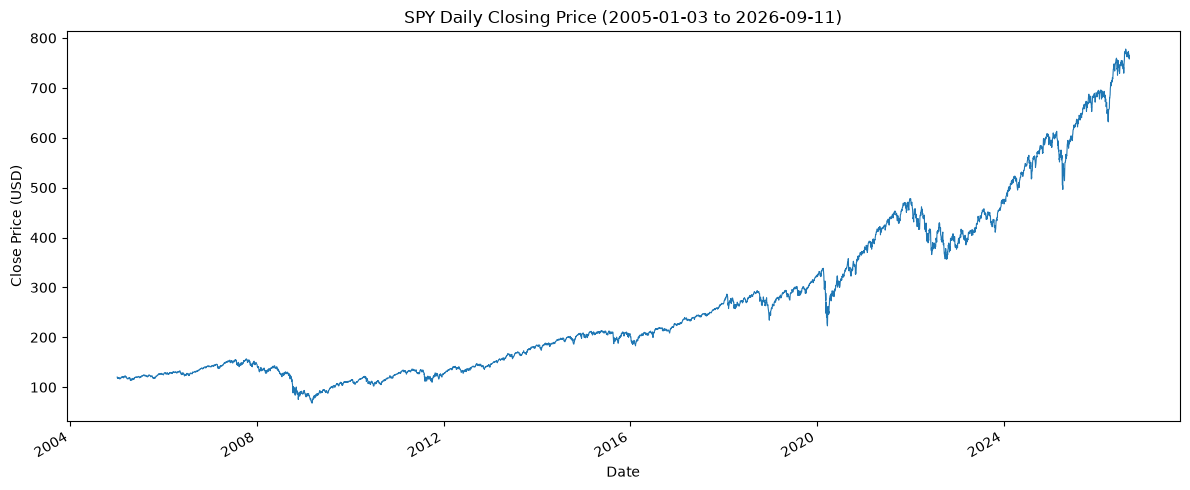

Saved figure to figures\spy_close_price.png


In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["Date"], df["Close"], linewidth=0.8, color="#1f77b4")
ax.set_title(f"{config.SYMBOL} Daily Closing Price ({df['Date'].min().date()} to {df['Date'].max().date()})")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
fig.autofmt_xdate()
fig.tight_layout()

figure_path = config.FIGURES_DIR / "spy_close_price.png"
fig.savefig(figure_path, dpi=150)
plt.show()

print(f"Saved figure to {figure_path.relative_to(PROJECT_ROOT)}")

## 6. Target Construction

**Definition.** For trading day `t`:

```
Target[t] = 1   if Close[t+1] >  Close[t]     (UP)
Target[t] = 0   if Close[t+1] <= Close[t]     (DOWN_OR_FLAT)
```

- `Close[t+1]` (tomorrow's close) is used **only** to compute the label for row `t`. It is never added to the returned DataFrame as its own column and must never become a model feature -- see Section 7 for an explicit audit of this.
- **Equal closes are DOWN_OR_FLAT (0), not discarded.** An unchanged price is not a directional "up" move, and silently dropping tie rows would shrink the dataset and bias the class balance based on an arbitrary choice.
- **The final row is dropped.** It has no following trading day, so no real target can be computed for it -- `build_target` removes it rather than fabricating a label.
- Implemented in `src/preprocessing.py::build_target`, which also validates that `Close` exists, is numeric, contains no NaNs, and (when a `Date` column is present) that dates are unique and sorted chronologically before touching anything.

In [6]:
from src.preprocessing import build_target

target_df = build_target(df)

print(f"Input rows (raw OHLCV):  {len(df)}")
print(f"Output rows (with Target): {len(target_df)}  (expected: {len(df) - 1}, i.e. one fewer -- the final unlabeled row was dropped)")
print(f"Columns: {list(target_df.columns)}")
print()
print("Target value counts:")
print(target_df['Target'].value_counts().sort_index())
assert len(target_df) == len(df) - 1
assert set(target_df["Target"].unique()) <= {0, 1}
print()
print("OK: exactly one row was dropped and Target is strictly binary.")

Input rows (raw OHLCV):  5457
Output rows (with Target): 5456  (expected: 5456, i.e. one fewer -- the final unlabeled row was dropped)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Target']

Target value counts:
Target
0    2476
1    2980
Name: count, dtype: int64

OK: exactly one row was dropped and Target is strictly binary.


## 7. Leak-Free Verification

At date `t`, the target represents whether the next trading day's Close is higher than today's Close. **The next day's Close is used only to construct the label and is never included as a model feature.**

The table below makes this explicit for human auditing: it shows `Close[t]` (today, a legitimate feature-time value) next to `Close[t+1]` (tomorrow, label-construction only) and the resulting `Target`. The `Close[t+1]` column exists **only in this display** -- it is not part of `target_df` and will never be part of any feature matrix built in later phases.

In [7]:
import pandas as pd

# This verification table is built directly from the raw `df` (not
# `target_df`) purely for display purposes, so the "not a feature" column is
# never at risk of being mistaken for part of the modeling DataFrame.
verification_df = pd.DataFrame(
    {
        "Date": df["Date"].iloc[:-1].values,
        "Close_t": df["Close"].iloc[:-1].values,
        "Close_t_plus_1__LABEL_ONLY_NOT_A_FEATURE": df["Close"].iloc[1:].values,
        "Target": target_df["Target"].values,
    }
)

print("Date | Close[t] | Close[t+1] (USED ONLY FOR LABEL CONSTRUCTION -- NOT A MODEL FEATURE) | Target")
display(verification_df.head(10))
print("...")
display(verification_df.tail(10))

# Manually obvious check: Target must equal 1 exactly where Close[t+1] > Close[t].
manual_target = (verification_df["Close_t_plus_1__LABEL_ONLY_NOT_A_FEATURE"] > verification_df["Close_t"]).astype(int)
assert (manual_target == verification_df["Target"]).all(), "Target does not match the manual Close[t+1] > Close[t] check."
print()
print("OK: Target matches a manual, independently-recomputed Close[t+1] > Close[t] check on every row.")

Date | Close[t] | Close[t+1] (USED ONLY FOR LABEL CONSTRUCTION -- NOT A MODEL FEATURE) | Target


,Date,Close_t,Close_t_plus_1__LABEL_ONLY_NOT_A_FEATURE,Target
0,2005-01-03,120.300003,118.830002,0
1,2005-01-04,118.830002,118.010002,0
2,2005-01-05,118.010002,118.610001,1
3,2005-01-06,118.610001,118.440002,0
4,2005-01-07,118.440002,119.000000,1
5,2005-01-10,119.000000,118.180000,0
6,2005-01-11,118.180000,118.570000,1
7,2005-01-12,118.570000,117.620003,0
8,2005-01-13,117.620003,118.239998,1
9,2005-01-14,118.239998,119.470001,1


...


,Date,Close_t,Close_t_plus_1__LABEL_ONLY_NOT_A_FEATURE,Target
5446,2026-08-27,771.099976,769.349976,0
5447,2026-08-28,769.349976,767.049988,0
5448,2026-08-31,767.049988,761.780029,0
5449,2026-09-01,761.780029,765.159973,1
5450,2026-09-02,765.159973,773.169983,1
5451,2026-09-03,773.169983,770.190002,0
5452,2026-09-04,770.190002,765.960022,0
5453,2026-09-08,765.960022,762.400024,0
5454,2026-09-09,762.400024,757.830017,0
5455,2026-09-10,757.830017,764.289978,1



OK: Target matches a manual, independently-recomputed Close[t+1] > Close[t] check on every row.


### Explicit leakage assertions

Programmatic checks -- not just a visual spot check -- that the target-construction machinery hasn't leaked anything forward. No feature matrix exists yet (that's Phase 5+), so the assertions below establish the ground truth (`target_df`'s own structure) that any future feature matrix will be checked against via `assert_no_target_leakage`.

In [8]:
from src.preprocessing import assert_no_target_leakage

# 1. The only new column added by build_target is "Target" itself -- no
#    temporary future-derived helper column (e.g. a raw Close[t+1] column)
#    survived into the returned DataFrame.
assert list(target_df.columns) == list(df.columns) + ["Target"], "Unexpected helper column(s) remained in target_df."

# 2. The final row without a target does not remain.
assert target_df["Date"].max() < df["Date"].max(), "The final (unlabeled) row was not dropped."
assert len(target_df) == len(df) - 1

# 3. Target is strictly binary.
assert set(target_df["Target"].unique()) <= {0, 1}

# 4. A hypothetical feature-column list is checked against the target column
#    and known future-derived helper names (the real check used once a
#    feature matrix exists in Phase 6+).
assert_no_target_leakage(["Open", "High", "Low", "Close", "Volume"])  # OK: no target, no helper columns
try:
    assert_no_target_leakage(["Open", "Close", "Target"])
    raise RuntimeError("assert_no_target_leakage should have rejected a feature list containing Target.")
except AssertionError:
    pass

print("OK: all explicit leakage assertions passed.")

OK: all explicit leakage assertions passed.


## 8. Class Balance

Reports the distribution of the binary target across the full dataset and across each chronological partition (train/validation/test). The chronological split itself -- exact date ranges, row counts, and the ordering guarantee -- is detailed formally in Section 9 immediately below; it is computed once in the next cell and reused there, so the numbers in both sections come from the same split object.

In [9]:
from src.preprocessing import chronological_split, compute_class_balance, print_class_balance

# Computed here (rather than in Section 9) because per-partition class
# balance needs the split to already exist; Section 9 reuses these same
# train_df/validation_df/test_df objects for its detailed date-range report.
train_df, validation_df, test_df = chronological_split(target_df, config.TRAIN_RATIO, config.VALIDATION_RATIO)

overall_balance = compute_class_balance(target_df["Target"])
print_class_balance(overall_balance, label="full dataset")
print()
train_balance = compute_class_balance(train_df["Target"])
print_class_balance(train_balance, label="train")
print()
validation_balance = compute_class_balance(validation_df["Target"])
print_class_balance(validation_balance, label="validation")
print()
test_balance = compute_class_balance(test_df["Target"])
print_class_balance(test_balance, label="test")

Class balance (full dataset):
  Total observations: 5456
  UP (1):           2980 (54.62%)
  DOWN_OR_FLAT (0): 2476 (45.38%)

Class balance (train):
  Total observations: 3819
  UP (1):           2082 (54.52%)
  DOWN_OR_FLAT (0): 1737 (45.48%)

Class balance (validation):
  Total observations: 818
  UP (1):           435 (53.18%)
  DOWN_OR_FLAT (0): 383 (46.82%)

Class balance (test):
  Total observations: 819
  UP (1):           463 (56.53%)
  DOWN_OR_FLAT (0): 356 (43.47%)


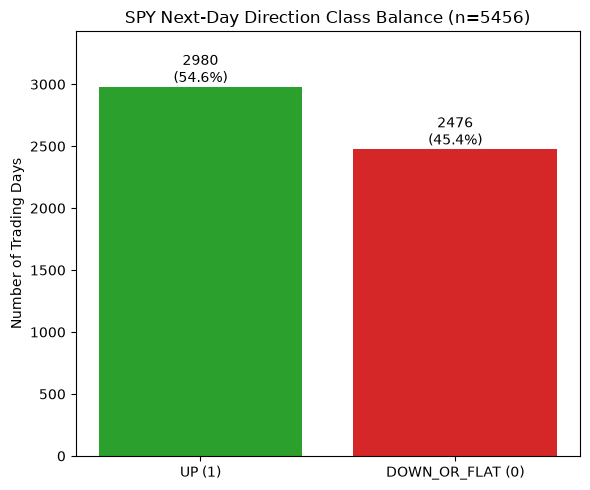

Saved figure to figures\class_balance.png


In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
labels = ["UP (1)", "DOWN_OR_FLAT (0)"]
counts = [overall_balance["n_up"], overall_balance["n_down_or_flat"]]
bars = ax.bar(labels, counts, color=["#2ca02c", "#d62728"])
ax.set_title(f"{config.SYMBOL} Next-Day Direction Class Balance (n={overall_balance['n_total']})")
ax.set_ylabel("Number of Trading Days")
ax.set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars, counts):
    pct = 100 * count / overall_balance["n_total"]
    ax.annotate(f"{count}\n({pct:.1f}%)", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom")
fig.tight_layout()

figure_path = config.FIGURES_DIR / "class_balance.png"
fig.savefig(figure_path, dpi=150)
plt.show()

print(f"Saved figure to {figure_path.relative_to(PROJECT_ROOT)}")

## 9. Chronological Train/Validation/Test Split

The oldest `TRAIN_RATIO` (70%) of rows form the training set, the next `VALIDATION_RATIO` (15%) form the validation set, and the remaining ~15% form the test set -- split strictly by chronological row order using the ratios already defined in `config.py`. **No shuffling, no random sampling, and no `sklearn.train_test_split` anywhere.** `train_df`, `validation_df`, and `test_df` were already computed in Section 8 (needed there for per-partition class balance); this section reports their exact date ranges and verifies the ordering guarantee.

In [11]:
def _report_partition(name, part_df, total_rows):
    pct = 100 * len(part_df) / total_rows
    print(f"{name}:")
    print(f"  First date: {part_df['Date'].min().date()}")
    print(f"  Last date:  {part_df['Date'].max().date()}")
    print(f"  Rows: {len(part_df)} ({pct:.2f}% of {total_rows})")
    print()

total_rows = len(target_df)
_report_partition("TRAIN", train_df, total_rows)
_report_partition("VALIDATION", validation_df, total_rows)
_report_partition("TEST", test_df, total_rows)

assert train_df["Date"].max() < validation_df["Date"].min(), "Train/validation date ranges overlap or are out of order."
assert validation_df["Date"].max() < test_df["Date"].min(), "Validation/test date ranges overlap or are out of order."
print("OK: train_end < validation_start and validation_end < test_start (strictly chronological, no overlap)."
)

TRAIN:
  First date: 2005-01-03
  Last date:  2020-03-05
  Rows: 3819 (70.00% of 5456)

VALIDATION:
  First date: 2020-03-06
  Last date:  2023-06-05
  Rows: 818 (14.99% of 5456)

TEST:
  First date: 2023-06-06
  Last date:  2026-09-10
  Rows: 819 (15.01% of 5456)

OK: train_end < validation_start and validation_end < test_start (strictly chronological, no overlap).


## 10. Naive Baselines

Two rule-based baselines, evaluated with **zero model fitting**, establishing the honest reference point any real model (Phase 5+) must beat on the same chronological test partition (`test_df`).

### Persistence Baseline

**Persistence predicts that the next trading day's direction will match the most recently observed direction.**

Concretely, for evaluation row `t`: `prediction[t] = direction[t-1]`, where `direction[k] = 1 if Close[k] > Close[k-1] else 0`. This uses `Close[t-1]` and `Close[t-2]` only -- never `Close[t]`, never `Close[t+1]`, and never the row's own `Target` (using `Target[t]` to predict `Target[t]` would be circular, since `Target[t]` is itself defined using `Close[t+1]`).

The first prediction in the test window still needs a "previous day," which falls in the *validation* period -- that historical observation is real and already-observed, so `persistence_baseline` is given the full chronological history (`target_df`) for context and only uses `test_df` to determine which dates to predict for and how many predictions to return.

In [12]:
from src.baselines import persistence_baseline

persistence_predictions = persistence_baseline(target_df, test_df)

print(f"Number of persistence predictions: {len(persistence_predictions)} (test_df rows: {len(test_df)})")
assert len(persistence_predictions) == len(test_df)

print()
print("Small real example -- the first test-window prediction uses VALIDATION-period history:")
last_val_dates = validation_df[["Date", "Close"]].tail(2).reset_index(drop=True)
print(last_val_dates)
print(f"direction observed on {last_val_dates['Date'].iloc[1].date()}: "
      f"{'UP (1)' if last_val_dates['Close'].iloc[1] > last_val_dates['Close'].iloc[0] else 'DOWN_OR_FLAT (0)'}")
print(f"First test row: {test_df['Date'].iloc[0].date()}, Close={test_df['Close'].iloc[0]}")
print(f"Persistence prediction for that row: {persistence_predictions.iloc[0]}")

Number of persistence predictions: 819 (test_df rows: 819)

Small real example -- the first test-window prediction uses VALIDATION-period history:
        Date       Close
0 2023-06-02  427.920013
1 2023-06-05  427.100006
direction observed on 2023-06-05: DOWN_OR_FLAT (0)
First test row: 2023-06-06, Close=428.0299987792969
Persistence prediction for that row: 0


### Majority-Class Baseline

**The majority class is determined from the training partition only and then predicted for the evaluation partition.** Validation and test data are never consulted when choosing which class is "the majority" -- only `train_df["Target"]` is used. On an exact 50/50 tie the documented, fixed rule is to predict UP (1); this dataset is not a tie, so the tie-break does not actually activate here, but the behavior is deterministic and tested regardless.

In [13]:
from src.baselines import majority_class_baseline

majority_predictions = majority_class_baseline(train_df["Target"], n_predictions=len(test_df))

print(f"Train class counts -- UP: {train_balance['n_up']}, DOWN_OR_FLAT: {train_balance['n_down_or_flat']}")
print(f"Majority class selected from TRAIN ONLY: {majority_predictions.iloc[0]} "
      f"({'UP' if majority_predictions.iloc[0] == 1 else 'DOWN_OR_FLAT'})")
print(f"Number of majority predictions: {len(majority_predictions)} (test_df rows: {len(test_df)})")
assert len(majority_predictions) == len(test_df)
assert majority_predictions.nunique() == 1, "Majority baseline must predict a single constant class."

Train class counts -- UP: 2082, DOWN_OR_FLAT: 1737
Majority class selected from TRAIN ONLY: 1 (UP)
Number of majority predictions: 819 (test_df rows: 819)


### Baseline Evaluation and Comparison

Both baselines are evaluated on the identical chronological test target (`test_df["Target"]`), using the same positive-class convention (UP = 1). Metrics come from `src.evaluation.compute_classification_metrics`, which explicitly defines precision/recall/F1 as 0 in the (not applicable here) case where a predictor never predicts the positive class, rather than raising or silently warning.

In [14]:
from src.evaluation import build_comparison_table, compute_classification_metrics

persistence_metrics = compute_classification_metrics(test_df["Target"], persistence_predictions)
majority_metrics = compute_classification_metrics(test_df["Target"], majority_predictions)

print("Persistence metrics:", persistence_metrics)
print("Majority Class metrics:", majority_metrics)

# Independent manual cross-check of accuracy (never trust a single calculation blindly).
manual_persistence_accuracy = (persistence_predictions.values == test_df["Target"].values).mean()
manual_majority_accuracy = (majority_predictions.values == test_df["Target"].values).mean()
assert abs(manual_persistence_accuracy - persistence_metrics["accuracy"]) < 1e-9
assert abs(manual_majority_accuracy - majority_metrics["accuracy"]) < 1e-9
print()
print("OK: manually recomputed accuracy matches compute_classification_metrics for both baselines.")

comparison_table = build_comparison_table(
    {
        "Persistence": persistence_metrics,
        "Majority Class": majority_metrics,
    }
)
display(comparison_table)

results_path = config.RESULTS_DIR / "baseline_comparison.csv"
comparison_table.to_csv(results_path, index=False)
print(f"Saved comparison table to {results_path.relative_to(PROJECT_ROOT)}")

Persistence metrics: {'n_predictions': 819, 'accuracy': 0.5018315018315018, 'precision': 0.5593952483801296, 'recall': 0.5593952483801296, 'f1': 0.5593952483801296}
Majority Class metrics: {'n_predictions': 819, 'accuracy': 0.5653235653235653, 'precision': 0.5653235653235653, 'recall': 1.0, 'f1': 0.7223088923556942}

OK: manually recomputed accuracy matches compute_classification_metrics for both baselines.


,Model,Accuracy,Precision,Recall,F1
0,Persistence,0.501832,0.559395,0.559395,0.559395
1,Majority Class,0.565324,0.565324,1.000000,0.722309


Saved comparison table to results\baseline_comparison.csv


### Baseline Sanity Check

Real test observations, actual labels, and both baselines' actual predictions, side by side -- so the definitions above can be checked by eye rather than taken on faith.

In [15]:
sanity_df = pd.DataFrame(
    {
        "Date": test_df["Date"],
        "Actual": test_df["Target"].values,
        "Persistence": persistence_predictions.values,
        "Majority": majority_predictions.values,
    }
)

print("First 10 test-window rows:")
display(sanity_df.head(10))
print("Last 10 test-window rows:")
display(sanity_df.tail(10))

assert sanity_df["Majority"].nunique() == 1, "Majority column should be constant across the whole table."
print()
print("OK: Majority column is constant, and Persistence values above match the direction-of-the-previous-day rule.")

First 10 test-window rows:


,Date,Actual,Persistence,Majority
0,2023-06-06,0,0,1
1,2023-06-07,1,1,1
2,2023-06-08,1,0,1
3,2023-06-09,1,1,1
4,2023-06-12,1,1,1
5,2023-06-13,1,1,1
6,2023-06-14,1,1,1
7,2023-06-15,0,1,1
8,2023-06-16,0,1,1
9,2023-06-20,0,0,1


Last 10 test-window rows:


,Date,Actual,Persistence,Majority
809,2026-08-27,0,1,1
810,2026-08-28,0,1,1
811,2026-08-31,0,0,1
812,2026-09-01,1,0,1
813,2026-09-02,1,0,1
814,2026-09-03,0,1,1
815,2026-09-04,0,1,1
816,2026-09-08,0,0,1
817,2026-09-09,0,0,1
818,2026-09-10,1,0,1



OK: Majority column is constant, and Persistence values above match the direction-of-the-previous-day rule.


## 11. Raw Price/Volume Model

The first real machine-learning model in this project, using **only raw price/volume information** -- no technical indicators yet (those are a later phase).

1. **Why raw OHLCV features are being tested first:** Option A requires training a model on raw price/volume before retraining with engineered indicators, so this establishes a clean reference point for how much (if anything) indicators add later.
2. **Why lagged features are used:** at prediction time `t`, the model may only use information already observed at or before `t`. `Open_lag1[t] = Open[t-1]`, `Close_lag2[t] = Close[t-2]`, etc. -- every lagged value was observed strictly before `Target[t]` is decided, so using it as a feature cannot leak the outcome being predicted.
3. **How leakage is prevented:** `build_raw_features` (`src/features.py`) only ever uses `shift(k)` with a **positive** `k` -- never `shift(-1)`/`shift(-2)` (those are reserved exclusively for `build_target`). `Target` is never selected into the feature set, and `assert_no_target_leakage` audits this programmatically below.
4. **How missing initial lag rows are handled:** the first `max(lags) = 5` rows of the dataset can't have every lag populated (there isn't 5 days of preceding history) -- they are dropped, never forward/backward-filled or invented.
5. **How chronological splitting works:** features are built on the *entire* chronological `target_df` first (so the first rows of validation/test can correctly look back into the immediately preceding partition, exactly like the persistence baseline does), and are then assigned to the **existing** `train_df`/`validation_df`/`test_df` partitions by `Date` membership -- never re-split from scratch, so the test window stays byte-for-byte identical to the one the baselines were evaluated on.
6. **How `StandardScaler` is fitted only on training data:** `scaler.fit(X_train)` only; `X_val`/`X_test` are transformed with that already-fitted scaler, never refit.
7. **What Logistic Regression does, at a high level:** it fits a linear boundary in (scaled) feature space and outputs a probability of the positive class (UP); thresholding that probability at 0.5 gives the binary prediction.

### Building the Raw Features

In [16]:
from src.features import RAW_FEATURE_LAGS, build_raw_features

raw_features_df = build_raw_features(target_df)
raw_feature_columns = [c for c in raw_features_df.columns if c != "Date"]

rows_lost_to_lag = len(target_df) - len(raw_features_df)
print(f"Lags used: {RAW_FEATURE_LAGS}")
print(f"Feature columns ({len(raw_feature_columns)}): {raw_feature_columns}")
print(f"target_df rows: {len(target_df)}  ->  raw_features_df rows: {len(raw_features_df)}  "
      f"(lost {rows_lost_to_lag} row(s) at the very start of the timeline -- insufficient lag history)")
print()
print("Sample feature rows:")
display(raw_features_df.head(3))

Lags used: [1, 2, 3, 5]
Feature columns (20): ['Open_lag1', 'Open_lag2', 'Open_lag3', 'Open_lag5', 'High_lag1', 'High_lag2', 'High_lag3', 'High_lag5', 'Low_lag1', 'Low_lag2', 'Low_lag3', 'Low_lag5', 'Close_lag1', 'Close_lag2', 'Close_lag3', 'Close_lag5', 'Volume_lag1', 'Volume_lag2', 'Volume_lag3', 'Volume_lag5']
target_df rows: 5456  ->  raw_features_df rows: 5451  (lost 5 row(s) at the very start of the timeline -- insufficient lag history)

Sample feature rows:


,Date,Open_lag1,Open_lag2,Open_lag3,Open_lag5,High_lag1,High_lag2,High_lag3,High_lag5,Low_lag1,...,Low_lag3,Low_lag5,Close_lag1,Close_lag2,Close_lag3,Close_lag5,Volume_lag1,Volume_lag2,Volume_lag3,Volume_lag5
0,2005-01-10,118.970001,118.440002,118.739998,121.559998,119.230003,119.150002,119.250000,121.760002,118.129997,...,118.000000,119.900002,118.440002,118.610001,118.010002,120.300003,55847700.0,47814700.0,65667300.0,55748000.0
1,2005-01-11,118.339996,118.970001,118.440002,120.459999,119.459999,119.230003,119.150002,120.540001,118.339996,...,118.260002,118.440002,119.000000,118.440002,118.610001,118.830002,56563300.0,55847700.0,47814700.0,69167600.0
2,2005-01-12,118.639999,118.339996,118.970001,118.739998,118.739998,119.459999,119.230003,119.250000,117.989998,...,118.129997,118.000000,118.180000,119.000000,118.440002,118.010002,63099700.0,56563300.0,55847700.0,65667300.0


### Assigning Features to the Existing Chronological Split

In [17]:
features_with_target = raw_features_df.merge(target_df[["Date", "Target"]], on="Date", how="inner")

train_dates = set(train_df["Date"])
validation_dates = set(validation_df["Date"])
test_dates = set(test_df["Date"])

train_features_df = features_with_target[features_with_target["Date"].isin(train_dates)].reset_index(drop=True)
validation_features_df = features_with_target[features_with_target["Date"].isin(validation_dates)].reset_index(drop=True)
test_features_df = features_with_target[features_with_target["Date"].isin(test_dates)].reset_index(drop=True)

X_train, y_train = train_features_df[raw_feature_columns], train_features_df["Target"]
X_val, y_val = validation_features_df[raw_feature_columns], validation_features_df["Target"]
X_test, y_test = test_features_df[raw_feature_columns], test_features_df["Target"]

print(f"X_train shape: {X_train.shape}  (train_df had {len(train_df)} rows -- lost {len(train_df) - len(X_train)} to lag)")
print(f"X_val shape:   {X_val.shape}  (validation_df had {len(validation_df)} rows)")
print(f"X_test shape:  {X_test.shape}  (test_df had {len(test_df)} rows)")

assert len(X_val) == len(validation_df), "Validation partition should be fully intact (not at the start of the timeline)."
assert len(X_test) == len(test_df), "Test partition should be fully intact (not at the start of the timeline)."
print()
print("OK: validation and test partitions are fully intact; only the training partition lost rows to lag creation.")

X_train shape: (3814, 20)  (train_df had 3819 rows -- lost 5 to lag)
X_val shape:   (818, 20)  (validation_df had 818 rows)
X_test shape:  (819, 20)  (test_df had 819 rows)

OK: validation and test partitions are fully intact; only the training partition lost rows to lag creation.


### Feature Leakage Audit

In [18]:
from src.preprocessing import assert_no_target_leakage

forbidden_substrings = ["future", "next_close", "close_plus", "close_tomorrow", "target_shifted", "tomorrow"]
suspicious_names = [c for c in raw_feature_columns if any(s in c.lower() for s in forbidden_substrings)]
assert not suspicious_names, f"Feature name(s) suggest future information: {suspicious_names}"

assert "Target" not in raw_feature_columns, "Target must not appear in the feature column list."
assert_no_target_leakage(raw_feature_columns)  # also checks known future-derived helper names

print(f"Checked {len(raw_feature_columns)} feature names for forbidden future-looking substrings: none found.")
print("'Target' confirmed absent from the feature column list.")
print("OK: feature leakage audit passed.")

Checked 20 feature names for forbidden future-looking substrings: none found.
'Target' confirmed absent from the feature column list.
OK: feature leakage audit passed.


### Time-Order Audit

In [19]:
print(f"Train:      {X_train.index.min()}..{X_train.index.max()} positions | dates {train_features_df['Date'].min().date()} to {train_features_df['Date'].max().date()}")
print(f"Validation: dates {validation_features_df['Date'].min().date()} to {validation_features_df['Date'].max().date()}")
print(f"Test:       dates {test_features_df['Date'].min().date()} to {test_features_df['Date'].max().date()}")

assert train_features_df["Date"].max() < validation_features_df["Date"].min(), "Train/validation overlap or are out of order."
assert validation_features_df["Date"].max() < test_features_df["Date"].min(), "Validation/test overlap or are out of order."
print()
print("OK: max(train dates) < min(validation dates) < max(validation dates) < min(test dates). No overlap, no shuffling, no random split.")

Train:      0..3813 positions | dates 2005-01-10 to 2020-03-05
Validation: dates 2020-03-06 to 2023-06-05
Test:       dates 2023-06-06 to 2026-09-10

OK: max(train dates) < min(validation dates) < max(validation dates) < min(test dates). No overlap, no shuffling, no random split.


### Training-Only Standard Scaling

`StandardScaler` learns a mean and standard deviation per feature from `X_train` **only**, then applies that same fixed transform to `X_val`/`X_test` -- it is never re-fit on them. To make this concrete rather than just asserted: after scaling, `X_train`'s per-feature mean/std should land at ~0/~1 (that's what "fitting on train" does, by definition) -- but `X_test`, scaled with `X_train`'s parameters, will generally NOT land at exactly 0/1, because its own distribution is different. That gap is expected and is direct evidence the scaler was never fit on test data.

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)  # fit on TRAINING data only

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Raw X_train feature means (first 5 features):", X_train.iloc[:, :5].mean().round(2).tolist())
print("Scaled X_train means (first 5, should be ~0):", X_train_scaled[:, :5].mean(axis=0).round(4).tolist())
print("Scaled X_train stds  (first 5, should be ~1):", X_train_scaled[:, :5].std(axis=0).round(4).tolist())
print()
print("Scaled X_test means  (first 5, NOT expected to be ~0 -- proves the scaler used TRAIN's parameters, not test's):",
      X_test_scaled[:, :5].mean(axis=0).round(4).tolist())
print("Scaled X_test stds   (first 5, NOT expected to be ~1):", X_test_scaled[:, :5].std(axis=0).round(4).tolist())

Raw X_train feature means (first 5 features): [173.72, 173.67, 173.62, 173.53, 174.63]
Scaled X_train means (first 5, should be ~0): [-0.0, -0.0, 0.0, -0.0, -0.0]
Scaled X_train stds  (first 5, should be ~1): [1.0, 1.0, 1.0, 1.0, 1.0]

Scaled X_test means  (first 5, NOT expected to be ~0 -- proves the scaler used TRAIN's parameters, not test's): [6.6421, 6.6395, 6.6369, 6.6299, 6.6609]
Scaled X_test stds   (first 5, NOT expected to be ~1): [1.5844, 1.5846, 1.5848, 1.5845, 1.5855]


### Training and Evaluating Logistic Regression

In [21]:
from src.models import train_logistic_regression

raw_model = train_logistic_regression(X_train_scaled, y_train, config.RANDOM_SEED)

raw_predictions = raw_model.predict(X_test_scaled)
raw_probabilities = raw_model.predict_proba(X_test_scaled)[:, 1]  # P(UP)

print(f"Number of predictions: {len(raw_predictions)} (y_test: {len(y_test)})")
assert len(raw_predictions) == len(y_test)

raw_metrics = compute_classification_metrics(y_test, raw_predictions)
print("Raw Logistic Regression metrics:", raw_metrics)

# Independent manual cross-check -- never trust a single calculation blindly.
manual_accuracy = (raw_predictions == y_test.values).mean()
assert abs(manual_accuracy - raw_metrics["accuracy"]) < 1e-9
print(f"Manual accuracy cross-check: {manual_accuracy:.6f} (matches compute_classification_metrics)")

Number of predictions: 819 (y_test: 819)

Raw Logistic Regression metrics: {'n_predictions': 819, 'accuracy': 0.5128205128205128, 'precision': 0.5586080586080586, 'recall': 0.6587473002159827, 'f1': 0.6045589692765114}
Manual accuracy cross-check: 0.512821 (matches compute_classification_metrics)


### Comparison with the Naive Baselines

Honest comparison, not a claim of success: the raw model is compared directly against Persistence and Majority Class on the identical test target (`y_test`, the same 819 rows as `test_df["Target"]`).

In [22]:
raw_model_comparison_table = build_comparison_table(
    {
        "Persistence": persistence_metrics,
        "Majority Class": majority_metrics,
        "Raw Logistic Regression": raw_metrics,
    }
)
display(raw_model_comparison_table)

raw_results_path = config.RESULTS_DIR / "raw_model_comparison.csv"
raw_model_comparison_table.to_csv(raw_results_path, index=False)
print(f"Saved comparison table to {raw_results_path.relative_to(PROJECT_ROOT)}")
print(f"(results/baseline_comparison.csv from Phase 4 is left untouched -- this is a separate, additive file.)")

better_than_persistence = raw_metrics["accuracy"] > persistence_metrics["accuracy"]
better_than_majority = raw_metrics["accuracy"] > majority_metrics["accuracy"]
print()
print(f"Raw model accuracy vs. Persistence: {'higher' if better_than_persistence else 'not higher'} "
      f"({raw_metrics['accuracy']:.4f} vs {persistence_metrics['accuracy']:.4f})")
print(f"Raw model accuracy vs. Majority Class: {'higher' if better_than_majority else 'not higher'} "
      f"({raw_metrics['accuracy']:.4f} vs {majority_metrics['accuracy']:.4f})")

,Model,Accuracy,Precision,Recall,F1
0,Persistence,0.501832,0.559395,0.559395,0.559395
1,Majority Class,0.565324,0.565324,1.000000,0.722309
2,Raw Logistic Regression,0.512821,0.558608,0.658747,0.604559


Saved comparison table to results\raw_model_comparison.csv
(results/baseline_comparison.csv from Phase 4 is left untouched -- this is a separate, additive file.)

Raw model accuracy vs. Persistence: higher (0.5128 vs 0.5018)
Raw model accuracy vs. Majority Class: not higher (0.5128 vs 0.5653)


### Prediction Sanity Check

Real test observations, actual labels, the raw model's actual predictions, and its predicted probability of UP, side by side.

In [23]:
raw_sanity_df = pd.DataFrame(
    {
        "Date": test_features_df["Date"],
        "Actual": y_test.values,
        "Raw Model Prediction": raw_predictions,
        "Predicted Probability of UP": raw_probabilities.round(4),
    }
)

print("First 10 test-window rows:")
display(raw_sanity_df.head(10))
print("Last 10 test-window rows:")
display(raw_sanity_df.tail(10))

First 10 test-window rows:


,Date,Actual,Raw Model Prediction,Predicted Probability of UP
0,2023-06-06,0,1,0.5187
1,2023-06-07,1,1,0.5044
2,2023-06-08,1,1,0.5019
3,2023-06-09,1,1,0.5165
4,2023-06-12,1,1,0.5448
5,2023-06-13,1,1,0.5099
6,2023-06-14,1,1,0.5196
7,2023-06-15,0,0,0.4849
8,2023-06-16,0,0,0.4936
9,2023-06-20,0,0,0.4986


Last 10 test-window rows:


,Date,Actual,Raw Model Prediction,Predicted Probability of UP
809,2026-08-27,0,1,0.5064
810,2026-08-28,0,1,0.5106
811,2026-08-31,0,0,0.4831
812,2026-09-01,1,0,0.4786
813,2026-09-02,1,0,0.4958
814,2026-09-03,0,1,0.5381
815,2026-09-04,0,1,0.5481
816,2026-09-08,0,0,0.4939
817,2026-09-09,0,0,0.4701
818,2026-09-10,1,0,0.4807


## 12. Technical Indicators

Five causal indicators, computed via the `ta` library (never `pandas-ta`, which is unmaintained) or plain pandas -- **feature engineering only in this section; the engineered-feature model itself is trained in the next phase**, so results here are indicator values, not predictions.

| Indicator | Window | What it measures | Why it might help predict direction | Why it does not leak the future |
|---|---|---|---|---|
| `SMA_10`, `SMA_20` | 10, 20 days | Trailing average closing price -- a smoothed view of the recent trend. | Price relative to its recent average is a classic momentum/mean-reversion signal. | `rolling(window).mean()` with no `center=True` -- only looks backward from `t`. |
| `RSI_14` | 14 days | Ratio of recent average gains to average losses, scaled to 0-100 (`ta.momentum.RSIIndicator`). | Extreme readings (near 0 or 100) often precede a reversal or continuation. | Computed from trailing gains/losses through day `t` only. |
| `MACD`, `MACD_SIGNAL`, `MACD_HIST` | 12/26/9 days | Difference between a fast and slow EMA of Close, plus a signal line and their difference (`ta.trend.MACD`). | MACD crossovers are a widely used trend-change signal. | EMAs are recursive but strictly backward-looking; never a centered window or future value. |
| `RETURN_1D` | 1 day | Today's percentage price change (`Close.pct_change(1)`). | The simplest possible momentum/reversal signal. | Uses only `Close[t]` and `Close[t-1]`, both known by end of day `t`. |
| `VOLATILITY_20` | 20 days | Rolling standard deviation of `RETURN_1D`. | Volatility regime affects how reliable directional signals are. | Trailing `rolling(window).std()` of an already-causal return series. |

**Timing relationship (why this isn't leakage):** `Target[t] = 1 if Close[t+1] > Close[t]`. Every indicator above is computed using information available *through* day `t` -- e.g. `RSI_14[t]` only reflects gains/losses up to and including day `t`. Using `RSI_14[t]` to predict `Target[t]` is valid precisely because the indicator never needed to see day `t+1` to exist.

### Building the Technical Indicators

In [24]:
from src.features import TECHNICAL_INDICATOR_WINDOWS, build_technical_indicators

indicator_df = build_technical_indicators(target_df)
indicator_columns = [c for c in indicator_df.columns if c != "Date"]

rows_lost_to_warmup = len(target_df) - len(indicator_df)
print(f"Windows used: {TECHNICAL_INDICATOR_WINDOWS}")
print(f"Indicator columns ({len(indicator_columns)}): {indicator_columns}")
print(f"target_df rows: {len(target_df)}  ->  indicator_df rows: {len(indicator_df)}  "
      f"(lost {rows_lost_to_warmup} row(s) to indicator warm-up -- MACD's 26+9-day requirement is the longest)")
print(f"Date range after warm-up trimming: {indicator_df['Date'].min().date()} to {indicator_df['Date'].max().date()}")
print()
print("Sample real rows (Date, Close, and every indicator):")
sample = indicator_df.merge(target_df[["Date", "Close"]], on="Date")[["Date", "Close"] + indicator_columns]
display(sample.head(5))
display(sample.tail(5))

Windows used: {'SMA_10': 10, 'SMA_20': 20, 'RSI_14': 14, 'MACD_WINDOW_FAST': 12, 'MACD_WINDOW_SLOW': 26, 'MACD_WINDOW_SIGNAL': 9, 'VOLATILITY_20': 20, 'RETURN_1D': 1}
Indicator columns (8): ['SMA_10', 'SMA_20', 'RSI_14', 'MACD', 'MACD_SIGNAL', 'MACD_HIST', 'RETURN_1D', 'VOLATILITY_20']
target_df rows: 5456  ->  indicator_df rows: 5423  (lost 33 row(s) to indicator warm-up -- MACD's 26+9-day requirement is the longest)
Date range after warm-up trimming: 2005-02-18 to 2026-09-10

Sample real rows (Date, Close, and every indicator):


,Date,Close,SMA_10,SMA_20,RSI_14,MACD,MACD_SIGNAL,MACD_HIST,RETURN_1D,VOLATILITY_20
0,2005-02-18,120.389999,120.373999,119.2395,56.635311,0.528558,0.419039,0.109519,0.001331,0.004667
1,2005-02-22,118.599998,120.226999,119.3420,43.783111,0.367698,0.408771,-0.041073,-0.014868,0.005904
2,2005-02-23,119.449997,120.150999,119.4705,49.628635,0.305284,0.388073,-0.082789,0.007167,0.006056
3,2005-02-24,120.239998,120.243999,119.6210,54.376907,0.315925,0.373644,-0.057719,0.006614,0.006169
4,2005-02-25,121.430000,120.412999,119.8210,60.428132,0.415591,0.382033,0.033558,0.009897,0.006463


,Date,Close,SMA_10,SMA_20,RSI_14,MACD,MACD_SIGNAL,MACD_HIST,RETURN_1D,VOLATILITY_20
5418,2026-09-03,773.169983,766.878986,769.206494,58.791150,3.070961,3.900332,-0.829371,0.010468,0.005215
5419,2026-09-04,770.190002,767.325989,769.052994,55.611385,3.070004,3.734266,-0.664262,-0.003854,0.005106
5420,2026-09-08,765.960022,767.574994,768.699493,51.364632,2.696833,3.526780,-0.829946,-0.005492,0.005243
5421,2026-09-09,762.400024,767.223999,768.291495,48.039652,2.089742,3.239372,-1.149630,-0.004648,0.005292
5422,2026-09-10,757.830017,766.398999,767.558496,44.093687,1.225727,2.836643,-1.610916,-0.005994,0.005377


### Indicator Sanity Checks

In [25]:
print(f"RSI_14 range: [{indicator_df['RSI_14'].min():.2f}, {indicator_df['RSI_14'].max():.2f}] (theoretical bounds: [0, 100])")
print(f"VOLATILITY_20 minimum: {indicator_df['VOLATILITY_20'].min():.6f} (must be >= 0)")
print(f"Any NaN remaining: {indicator_df[indicator_columns].isna().any().any()}")
print(f"Any infinite values: {bool(indicator_df[indicator_columns].apply(lambda s: (~s.apply(lambda v: v == v and abs(v) != float('inf'))).any()).any())}")

assert indicator_df["RSI_14"].between(0, 100).all(), "RSI_14 must lie within [0, 100]."
assert (indicator_df["VOLATILITY_20"] >= 0).all(), "VOLATILITY_20 must be non-negative."
assert not indicator_df[indicator_columns].isna().any().any(), "No NaN should remain after warm-up trimming."
print()
print("OK: all indicator sanity checks passed on the real dataset.")

RSI_14 range: [16.70, 87.03] (theoretical bounds: [0, 100])
VOLATILITY_20 minimum: 0.002010 (must be >= 0)
Any NaN remaining: False
Any infinite values: False

OK: all indicator sanity checks passed on the real dataset.


### Feature Leakage Assertions

In [26]:
from src.preprocessing import assert_no_target_leakage

# 1. Target is not in the engineered features.
assert "Target" not in indicator_columns

# 2. No future-suggesting column names.
forbidden_substrings = ["future", "next_close", "close_plus", "close_tomorrow", "target_shifted", "tomorrow"]
suspicious_names = [c for c in indicator_columns if any(s in c.lower() for s in forbidden_substrings)]
assert not suspicious_names, f"Feature name(s) suggest future information: {suspicious_names}"

# 3. No negative shifts or centered rolling windows anywhere in the source.
import inspect
from src import features as features_module
source_code = inspect.getsource(features_module.build_technical_indicators)
assert "shift(-" not in source_code, "build_technical_indicators must never use a negative shift."
assert "center=True" not in source_code, "build_technical_indicators must never use a centered rolling window."

# 4. Feature timestamps remain chronological.
assert indicator_df["Date"].is_monotonic_increasing

assert_no_target_leakage(indicator_columns)

print(f"Checked {len(indicator_columns)} indicator names and the source code of build_technical_indicators.")
print("OK: no Target leakage, no future-suggesting names, no negative shift, no centered window, dates chronological.")

Checked 8 indicator names and the source code of build_technical_indicators.
OK: no Target leakage, no future-suggesting names, no negative shift, no centered window, dates chronological.


### Perturbation Causality Test

The strongest practical proof of causality: change a single future observation and confirm every earlier indicator value is completely unaffected.

In [27]:
indicators_before = build_technical_indicators(target_df)

perturbed_target_df = target_df.copy()
perturbed_target_df.loc[perturbed_target_df.index[-1], "Close"] = 999999.0  # change ONLY the last observation
indicators_after = build_technical_indicators(perturbed_target_df)

# Rows well clear of the perturbed timestamp (beyond the longest window
# used, 26+9 for MACD) must be byte-for-byte identical.
cutoff = 40
pd.testing.assert_frame_equal(
    indicators_before.iloc[:-cutoff].reset_index(drop=True),
    indicators_after.iloc[:-cutoff].reset_index(drop=True),
)
print(f"Perturbed the last observation's Close to 999999.0 and rebuilt all {len(indicator_columns)} indicators.")
print(f"Confirmed all rows more than {cutoff} rows before the perturbation are UNCHANGED (byte-for-byte identical).")
print("OK: perturbation causality test passed.")

Perturbed the last observation's Close to 999999.0 and rebuilt all 8 indicators.
Confirmed all rows more than 40 rows before the perturbation are UNCHANGED (byte-for-byte identical).
OK: perturbation causality test passed.


### Visualizations

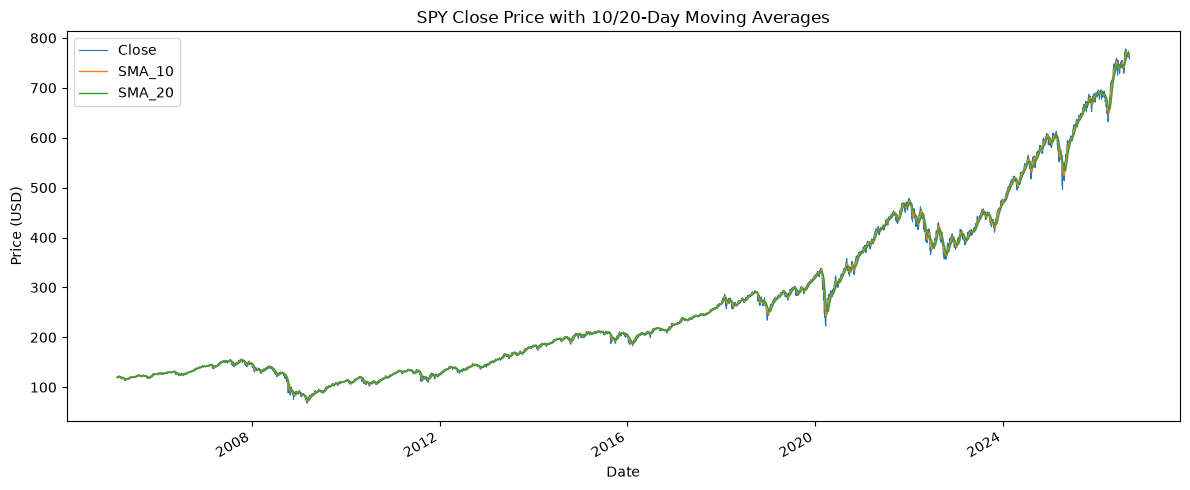

Saved figure to figures\close_with_sma.png


In [28]:
plot_df = indicator_df.merge(target_df[["Date", "Close"]], on="Date")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_df["Date"], plot_df["Close"], label="Close", linewidth=0.8, color="#1f77b4")
ax.plot(plot_df["Date"], plot_df["SMA_10"], label="SMA_10", linewidth=1.0, color="#ff7f0e")
ax.plot(plot_df["Date"], plot_df["SMA_20"], label="SMA_20", linewidth=1.0, color="#2ca02c")
ax.set_title(f"{config.SYMBOL} Close Price with 10/20-Day Moving Averages")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()

figure_path = config.FIGURES_DIR / "close_with_sma.png"
fig.savefig(figure_path, dpi=150)
plt.show()
print(f"Saved figure to {figure_path.relative_to(PROJECT_ROOT)}")

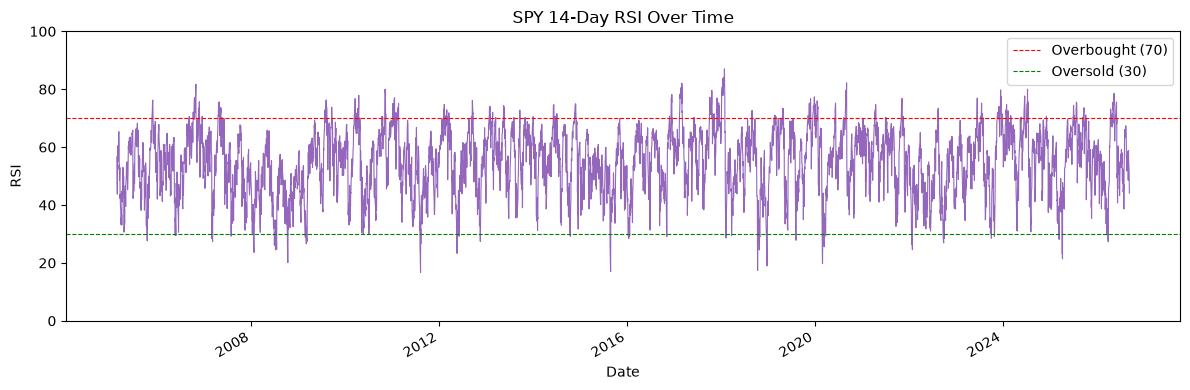

Saved figure to figures\rsi_over_time.png


In [29]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(plot_df["Date"], plot_df["RSI_14"], linewidth=0.8, color="#9467bd")
ax.axhline(70, color="red", linestyle="--", linewidth=0.8, label="Overbought (70)")
ax.axhline(30, color="green", linestyle="--", linewidth=0.8, label="Oversold (30)")
ax.set_title(f"{config.SYMBOL} 14-Day RSI Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("RSI")
ax.set_ylim(0, 100)
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()

figure_path = config.FIGURES_DIR / "rsi_over_time.png"
fig.savefig(figure_path, dpi=150)
plt.show()
print(f"Saved figure to {figure_path.relative_to(PROJECT_ROOT)}")

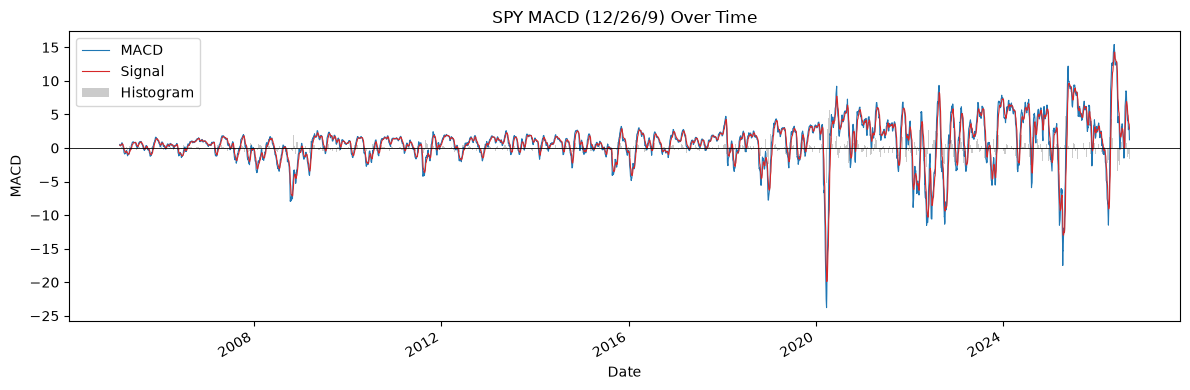

Saved figure to figures\macd_over_time.png


In [30]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(plot_df["Date"], plot_df["MACD"], label="MACD", linewidth=0.8, color="#1f77b4")
ax.plot(plot_df["Date"], plot_df["MACD_SIGNAL"], label="Signal", linewidth=0.8, color="#d62728")
ax.bar(plot_df["Date"], plot_df["MACD_HIST"], label="Histogram", color="#7f7f7f", width=1.0, alpha=0.4)
ax.axhline(0, color="black", linewidth=0.6)
ax.set_title(f"{config.SYMBOL} MACD (12/26/9) Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("MACD")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()

figure_path = config.FIGURES_DIR / "macd_over_time.png"
fig.savefig(figure_path, dpi=150)
plt.show()
print(f"Saved figure to {figure_path.relative_to(PROJECT_ROOT)}")

### Technical Indicator Feature Table

A concise, evaluator-friendly summary -- every "Uses Future Data?" value must read **No**.

In [31]:
feature_table = pd.DataFrame(
    [
        {"Feature": "SMA_10", "Type": "Moving Average", "Window": 10, "Uses Future Data?": "No", "Description": "10-day trailing average of Close"},
        {"Feature": "SMA_20", "Type": "Moving Average", "Window": 20, "Uses Future Data?": "No", "Description": "20-day trailing average of Close"},
        {"Feature": "RSI_14", "Type": "Momentum Oscillator", "Window": 14, "Uses Future Data?": "No", "Description": "14-day Relative Strength Index"},
        {"Feature": "MACD", "Type": "Trend", "Window": "12/26", "Uses Future Data?": "No", "Description": "Fast EMA minus slow EMA of Close"},
        {"Feature": "MACD_SIGNAL", "Type": "Trend", "Window": 9, "Uses Future Data?": "No", "Description": "EMA of the MACD line"},
        {"Feature": "MACD_HIST", "Type": "Trend", "Window": "12/26/9", "Uses Future Data?": "No", "Description": "MACD minus MACD_SIGNAL"},
        {"Feature": "RETURN_1D", "Type": "Return", "Window": 1, "Uses Future Data?": "No", "Description": "1-day percentage change in Close"},
        {"Feature": "VOLATILITY_20", "Type": "Volatility", "Window": 20, "Uses Future Data?": "No", "Description": "20-day rolling std. of RETURN_1D"},
    ]
)
display(feature_table)
assert (feature_table["Uses Future Data?"] == "No").all()

,Feature,Type,Window,Uses Future Data?,Description
0,SMA_10,Moving Average,10,No,10-day trailing average of Close
1,SMA_20,Moving Average,20,No,20-day trailing average of Close
2,RSI_14,Momentum Oscillator,14,No,14-day Relative Strength Index
3,MACD,Trend,12/26,No,Fast EMA minus slow EMA of Close
4,MACD_SIGNAL,Trend,9,No,EMA of the MACD line
5,MACD_HIST,Trend,12/26/9,No,MACD minus MACD_SIGNAL
6,RETURN_1D,Return,1,No,1-day percentage change in Close
7,VOLATILITY_20,Volatility,20,No,20-day rolling std. of RETURN_1D


### Note on the Engineered Feature Set

The full engineered feature set for the next phase's model will be `build_raw_features(target_df)` (the 20 lagged raw OHLCV columns from Phase 5) **plus** the 8 technical-indicator columns above -- raw features are not replaced, since the goal is to test whether indicators add signal *beyond* raw price/volume history, not instead of it. **No engineered-feature model is trained in this phase** -- that, along with the four-way comparison (Persistence vs. Majority vs. Raw vs. Engineered), is Phase 7's job.

## 13. Engineered Feature Model

The final model: **28 engineered features** (the 20 raw lagged OHLCV columns from Phase 5 + the 8 technical indicators from Phase 6), trained with the exact same deterministic `LogisticRegression` configuration and training-only-scaler discipline as the raw model, evaluated on the identical chronological test partition.

### Building the Engineered Feature Set

In [32]:
from src.features import ENGINEERED_FEATURE_COLUMNS, RAW_FEATURE_COLUMNS, TECHNICAL_INDICATOR_COLUMNS, build_engineered_features

assert len(RAW_FEATURE_COLUMNS) == 20
assert len(TECHNICAL_INDICATOR_COLUMNS) == 8
assert len(ENGINEERED_FEATURE_COLUMNS) == 28

engineered_df = build_engineered_features(target_df)
engineered_feature_columns = [c for c in engineered_df.columns if c != "Date"]
assert engineered_feature_columns == ENGINEERED_FEATURE_COLUMNS

rows_lost_to_warmup = len(target_df) - len(engineered_df)
print(f"Raw feature columns (20): {RAW_FEATURE_COLUMNS}")
print(f"Technical indicator columns (8): {TECHNICAL_INDICATOR_COLUMNS}")
print(f"Total engineered feature columns: {len(engineered_feature_columns)}")
print()
print(f"target_df rows: {len(target_df)}  ->  engineered_df rows: {len(engineered_df)}  "
      f"(lost {rows_lost_to_warmup} rows -- the technical-indicator warm-up (33 rows) dominates the raw-lag warm-up (5 rows), "
      f"so the engineered dataset starts wherever the indicators do)")
print(f"Date range after alignment: {engineered_df['Date'].min().date()} to {engineered_df['Date'].max().date()}")
print()
display(engineered_df.head(3))

Raw feature columns (20): ['Open_lag1', 'Open_lag2', 'Open_lag3', 'Open_lag5', 'High_lag1', 'High_lag2', 'High_lag3', 'High_lag5', 'Low_lag1', 'Low_lag2', 'Low_lag3', 'Low_lag5', 'Close_lag1', 'Close_lag2', 'Close_lag3', 'Close_lag5', 'Volume_lag1', 'Volume_lag2', 'Volume_lag3', 'Volume_lag5']
Technical indicator columns (8): ['SMA_10', 'SMA_20', 'RSI_14', 'MACD', 'MACD_SIGNAL', 'MACD_HIST', 'RETURN_1D', 'VOLATILITY_20']
Total engineered feature columns: 28

target_df rows: 5456  ->  engineered_df rows: 5423  (lost 33 rows -- the technical-indicator warm-up (33 rows) dominates the raw-lag warm-up (5 rows), so the engineered dataset starts wherever the indicators do)
Date range after alignment: 2005-02-18 to 2026-09-10



,Date,Open_lag1,Open_lag2,Open_lag3,Open_lag5,High_lag1,High_lag2,High_lag3,High_lag5,Low_lag1,...,Volume_lag3,Volume_lag5,SMA_10,SMA_20,RSI_14,MACD,MACD_SIGNAL,MACD_HIST,RETURN_1D,VOLATILITY_20
0,2005-02-18,121.230003,120.930000,120.800003,119.699997,121.330002,121.459999,121.430000,121.040001,120.220001,...,43852700.0,53133000.0,120.373999,119.2395,56.635311,0.528558,0.419039,0.109519,0.001331,0.004667
1,2005-02-22,120.239998,121.230003,120.930000,120.690002,120.480003,121.330002,121.459999,120.860001,119.900002,...,55523000.0,32432100.0,120.226999,119.3420,43.783111,0.367698,0.408771,-0.041073,-0.014868,0.005904
2,2005-02-23,119.900002,120.239998,121.230003,120.800003,120.470001,120.480003,121.330002,121.430000,118.580002,...,58124000.0,43852700.0,120.150999,119.4705,49.628635,0.305284,0.388073,-0.082789,0.007167,0.006056


### Assigning Engineered Features to the Existing Chronological Split

Exactly the same pattern as the raw model (Section 11): the existing `train_df`/`validation_df`/`test_df` partitions from Phase 3 are reused by `Date` membership -- never re-split -- so the official test period (2023-06-06 to 2026-09-10) stays identical across every model in this project.

In [33]:
engineered_with_target = engineered_df.merge(target_df[["Date", "Target"]], on="Date", how="inner")

train_engineered_df = engineered_with_target[engineered_with_target["Date"].isin(train_dates)].reset_index(drop=True)
validation_engineered_df = engineered_with_target[engineered_with_target["Date"].isin(validation_dates)].reset_index(drop=True)
test_engineered_df = engineered_with_target[engineered_with_target["Date"].isin(test_dates)].reset_index(drop=True)

X_train_eng = train_engineered_df[engineered_feature_columns]
y_train_eng = train_engineered_df["Target"]
X_val_eng = validation_engineered_df[engineered_feature_columns]
y_val_eng = validation_engineered_df["Target"]
X_test_eng = test_engineered_df[engineered_feature_columns]
y_test_eng = test_engineered_df["Target"]

print(f"X_train_eng shape: {X_train_eng.shape}  (train_df had {len(train_df)} rows -- lost {len(train_df) - len(X_train_eng)} to indicator warm-up)")
print(f"X_val_eng shape:   {X_val_eng.shape}  (validation_df had {len(validation_df)} rows)")
print(f"X_test_eng shape:  {X_test_eng.shape}  (test_df had {len(test_df)} rows)")

assert len(X_val_eng) == len(validation_df), "Validation partition should be fully intact."
assert len(X_test_eng) == len(test_df) == 819, "Test partition must be fully intact and match the official 819-row test window."
assert test_engineered_df["Date"].min() == test_df["Date"].min() and test_engineered_df["Date"].max() == test_df["Date"].max()
print()
print(f"Official test period preserved: {test_engineered_df['Date'].min().date()} to {test_engineered_df['Date'].max().date()} (819 observations).")
print("OK: validation and test partitions are fully intact; only the training partition lost rows to indicator warm-up.")

X_train_eng shape: (3786, 28)  (train_df had 3819 rows -- lost 33 to indicator warm-up)
X_val_eng shape:   (818, 28)  (validation_df had 818 rows)
X_test_eng shape:  (819, 28)  (test_df had 819 rows)

Official test period preserved: 2023-06-06 to 2026-09-10 (819 observations).
OK: validation and test partitions are fully intact; only the training partition lost rows to indicator warm-up.


### Feature Leakage Audit (Engineered Pipeline)

In [34]:
import inspect
from src import features as features_module
from src.preprocessing import assert_no_target_leakage

# 1. Target is not in the engineered features.
assert "Target" not in engineered_feature_columns

# 2. No future-suggesting column names.
forbidden_substrings = ["future", "next_close", "close_plus", "close_tomorrow", "target_shifted", "tomorrow"]
suspicious_names = [c for c in engineered_feature_columns if any(s in c.lower() for s in forbidden_substrings)]
assert not suspicious_names, f"Feature name(s) suggest future information: {suspicious_names}"

# 3. No negative shifts or centered rolling windows anywhere in the feature-construction source.
for fn in (features_module.build_raw_features, features_module.build_technical_indicators, features_module.build_engineered_features):
    source_code = inspect.getsource(fn)
    assert "shift(-" not in source_code, f"{fn.__name__} must never use a negative shift."
    assert "center=True" not in source_code, f"{fn.__name__} must never use a centered rolling window."

# 4. Dates remain chronological; the test period is unchanged; no NaNs anywhere in the final matrices.
assert engineered_df["Date"].is_monotonic_increasing
assert not X_train_eng.isna().any().any()
assert not X_val_eng.isna().any().any()
assert not X_test_eng.isna().any().any()

assert_no_target_leakage(engineered_feature_columns)

print(f"Checked {len(engineered_feature_columns)} engineered feature names and the source of all three feature-construction functions.")
print("OK: no Target leakage, no future-suggesting names, no negative shift, no centered window, dates chronological, no NaNs, test period unchanged.")

Checked 28 engineered feature names and the source of all three feature-construction functions.
OK: no Target leakage, no future-suggesting names, no negative shift, no centered window, dates chronological, no NaNs, test period unchanged.


### Time-Order Audit (Engineered Pipeline)

In [35]:
print(f"Train:      {train_engineered_df['Date'].min().date()} to {train_engineered_df['Date'].max().date()}")
print(f"Validation: {validation_engineered_df['Date'].min().date()} to {validation_engineered_df['Date'].max().date()}")
print(f"Test:       {test_engineered_df['Date'].min().date()} to {test_engineered_df['Date'].max().date()}")

assert train_engineered_df["Date"].max() < validation_engineered_df["Date"].min()
assert validation_engineered_df["Date"].max() < test_engineered_df["Date"].min()
print()
print("OK: max(train dates) < min(validation dates) < max(validation dates) < min(test dates). No overlap, no shuffling, no random split.")

Train:      2005-02-18 to 2020-03-05
Validation: 2020-03-06 to 2023-06-05
Test:       2023-06-06 to 2026-09-10

OK: max(train dates) < min(validation dates) < max(validation dates) < min(test dates). No overlap, no shuffling, no random split.


### Training-Only Standard Scaling (Engineered)

Same discipline as the raw model: `StandardScaler.fit(X_train_eng)` only -- never `fit`/`fit_transform` on validation or test data.

In [36]:
scaler_eng = StandardScaler()
scaler_eng.fit(X_train_eng)  # TRAINING data only

X_train_eng_scaled = scaler_eng.transform(X_train_eng)
X_val_eng_scaled = scaler_eng.transform(X_val_eng)
X_test_eng_scaled = scaler_eng.transform(X_test_eng)

print("Scaled X_train_eng means (first 5, should be ~0):", X_train_eng_scaled[:, :5].mean(axis=0).round(4).tolist())
print("Scaled X_train_eng stds  (first 5, should be ~1):", X_train_eng_scaled[:, :5].std(axis=0).round(4).tolist())
print("Scaled X_test_eng means  (first 5, NOT expected to be ~0 -- proves the scaler used TRAIN's parameters):",
      X_test_eng_scaled[:, :5].mean(axis=0).round(4).tolist())

Scaled X_train_eng means (first 5, should be ~0): [-0.0, 0.0, -0.0, -0.0, 0.0]
Scaled X_train_eng stds  (first 5, should be ~1): [1.0, 1.0, 1.0, 1.0, 1.0]
Scaled X_test_eng means  (first 5, NOT expected to be ~0 -- proves the scaler used TRAIN's parameters): [6.6305, 6.6279, 6.6254, 6.6182, 6.6495]


### Training the Engineered Logistic Regression

Same deterministic configuration as the raw model (`random_state=config.RANDOM_SEED`, `max_iter=1000`) -- only the feature set differs.

In [37]:
engineered_model = train_logistic_regression(X_train_eng_scaled, y_train_eng, config.RANDOM_SEED)

y_pred_engineered = engineered_model.predict(X_test_eng_scaled)
y_proba_engineered = engineered_model.predict_proba(X_test_eng_scaled)[:, 1]  # P(UP)

print(f"len(y_pred_engineered) = {len(y_pred_engineered)}")
print(f"len(y_test_eng) = {len(y_test_eng)}")
assert len(y_pred_engineered) == 819
assert len(y_test_eng) == 819

engineered_metrics = compute_classification_metrics(y_test_eng, y_pred_engineered)
print()
print("Engineered Logistic Regression")
print(f"Accuracy:  {engineered_metrics['accuracy']:.4f}")
print(f"Precision: {engineered_metrics['precision']:.4f}")
print(f"Recall:    {engineered_metrics['recall']:.4f}")
print(f"F1:        {engineered_metrics['f1']:.4f}")

manual_accuracy = (y_pred_engineered == y_test_eng.values).mean()
assert abs(manual_accuracy - engineered_metrics["accuracy"]) < 1e-9
print()
print(f"Manual accuracy cross-check: {manual_accuracy:.6f} (matches compute_classification_metrics)")

engineered_comparison_table = build_comparison_table({"Engineered Logistic Regression": engineered_metrics})
display(engineered_comparison_table)
engineered_results_path = config.RESULTS_DIR / "engineered_model_comparison.csv"
engineered_comparison_table.to_csv(engineered_results_path, index=False)
print(f"Saved to {engineered_results_path.relative_to(PROJECT_ROOT)}")

len(y_pred_engineered) = 819
len(y_test_eng) = 819

Engineered Logistic Regression
Accuracy:  0.4945
Precision: 0.5706
Recall:    0.4276
F1:        0.4889

Manual accuracy cross-check: 0.494505 (matches compute_classification_metrics)


,Model,Accuracy,Precision,Recall,F1
0,Engineered Logistic Regression,0.494505,0.570605,0.427646,0.488889


Saved to results\engineered_model_comparison.csv


## 14. Time-Series Evaluation

All four approaches -- Persistence, Majority Class, Raw Logistic Regression, and Engineered Logistic Regression -- have now been evaluated on the identical, untouched, chronologically-final test window (2023-06-06 to 2026-09-10, 819 observations). No model selection or tuning used this test window; it was touched only for final evaluation.

## 15. Four-Way Comparison

The final comparison, using the same metrics, the same positive-class convention (UP = 1), and the same 819-row test target for every model.

### Final Comparison Table

In [38]:
final_comparison_table = build_comparison_table(
    {
        "Persistence": persistence_metrics,
        "Majority Class": majority_metrics,
        "Raw Logistic Regression": raw_metrics,
        "Engineered Logistic Regression": engineered_metrics,
    }
)
display(final_comparison_table)

final_results_path = config.RESULTS_DIR / "final_comparison.csv"
final_comparison_table.to_csv(final_results_path, index=False)
print(f"Saved final four-way comparison to {final_results_path.relative_to(PROJECT_ROOT)}")

,Model,Accuracy,Precision,Recall,F1
0,Persistence,0.501832,0.559395,0.559395,0.559395
1,Majority Class,0.565324,0.565324,1.000000,0.722309
2,Raw Logistic Regression,0.512821,0.558608,0.658747,0.604559
3,Engineered Logistic Regression,0.494505,0.570605,0.427646,0.488889


Saved final four-way comparison to results\final_comparison.csv


### Required Performance Interpretation

Computed directly from `final_comparison_table` -- not asserted from memory.

In [39]:
best_accuracy_row = final_comparison_table.loc[final_comparison_table["Accuracy"].idxmax()]
best_f1_row = final_comparison_table.loc[final_comparison_table["F1"].idxmax()]

print(f"1. Highest accuracy: {best_accuracy_row['Model']} ({best_accuracy_row['Accuracy']:.4f})")
print(f"2. Highest F1:       {best_f1_row['Model']} ({best_f1_row['F1']:.4f})")
print()
print("3. Engineered vs. Raw Logistic Regression:")
for metric in ["Accuracy", "Precision", "Recall", "F1"]:
    eng_val = engineered_metrics[metric.lower()]
    raw_val = raw_metrics[metric.lower()]
    verdict = "beats" if eng_val > raw_val else ("ties" if eng_val == raw_val else "does NOT beat")
    print(f"   {metric}: engineered={eng_val:.4f} vs raw={raw_val:.4f}  -> engineered {verdict} raw")
print()
engineered_vs_majority = "beats" if engineered_metrics["accuracy"] > majority_metrics["accuracy"] else "does NOT beat"
print(f"4. Engineered vs. Majority Class on accuracy: engineered {engineered_vs_majority} majority "
      f"({engineered_metrics['accuracy']:.4f} vs {majority_metrics['accuracy']:.4f})")
print()
indicators_helped = engineered_metrics["accuracy"] > raw_metrics["accuracy"]
print(f"5. Did technical indicators improve the result? {'YES' if indicators_helped else 'NO'} -- "
      f"engineered accuracy ({engineered_metrics['accuracy']:.4f}) vs raw accuracy ({raw_metrics['accuracy']:.4f}).")
if not indicators_helped:
    print("   Under this setup (28 features, single Logistic Regression, no tuning), the technical")
    print("   indicators added to the raw price/volume features did NOT improve out-of-sample")
    print("   accuracy on the test period. This is reported honestly, not adjusted or hidden.")

1. Highest accuracy: Majority Class (0.5653)
2. Highest F1:       Majority Class (0.7223)

3. Engineered vs. Raw Logistic Regression:
   Accuracy: engineered=0.4945 vs raw=0.5128  -> engineered does NOT beat raw
   Precision: engineered=0.5706 vs raw=0.5586  -> engineered beats raw
   Recall: engineered=0.4276 vs raw=0.6587  -> engineered does NOT beat raw
   F1: engineered=0.4889 vs raw=0.6046  -> engineered does NOT beat raw

4. Engineered vs. Majority Class on accuracy: engineered does NOT beat majority (0.4945 vs 0.5653)

5. Did technical indicators improve the result? NO -- engineered accuracy (0.4945) vs raw accuracy (0.5128).
   Under this setup (28 features, single Logistic Regression, no tuning), the technical
   indicators added to the raw price/volume features did NOT improve out-of-sample
   accuracy on the test period. This is reported honestly, not adjusted or hidden.


## 16. Prediction Visualization

Predicted vs. actual next-day direction for the Engineered Logistic Regression, over the real test window.

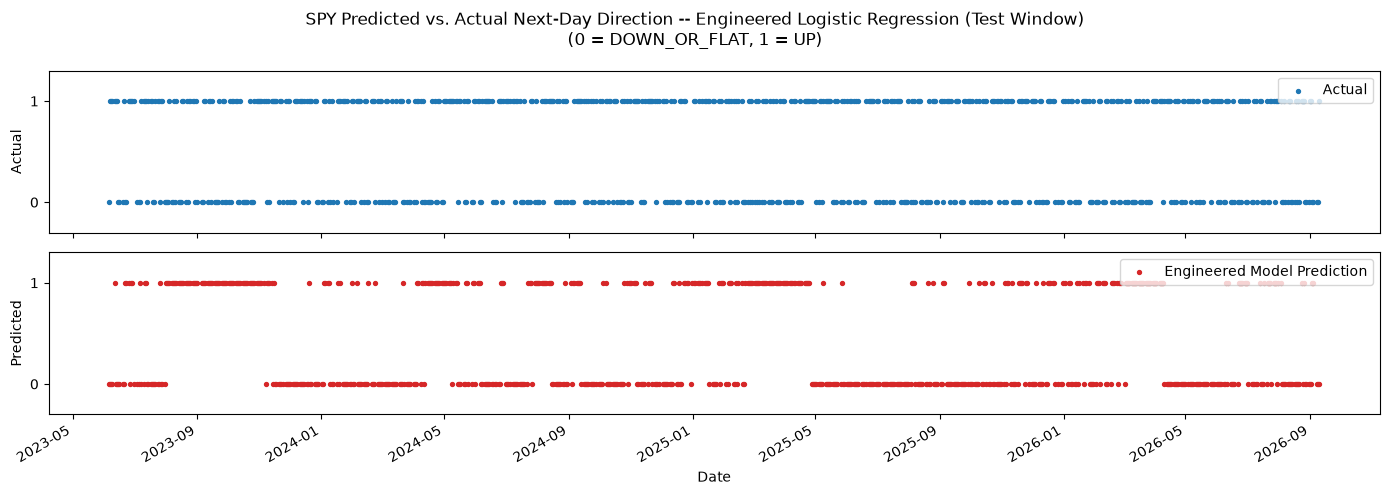

Saved figure to figures\predicted_vs_actual.png


In [40]:
fig, (ax_actual, ax_pred) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

ax_actual.scatter(test_engineered_df["Date"], y_test_eng.values, s=8, color="#1f77b4", label="Actual")
ax_actual.set_yticks([0, 1])
ax_actual.set_ylim(-0.3, 1.3)
ax_actual.set_ylabel("Actual")
ax_actual.legend(loc="upper right")

ax_pred.scatter(test_engineered_df["Date"], y_pred_engineered, s=8, color="#d62728", label="Engineered Model Prediction")
ax_pred.set_yticks([0, 1])
ax_pred.set_ylim(-0.3, 1.3)
ax_pred.set_xlabel("Date")
ax_pred.set_ylabel("Predicted")
ax_pred.legend(loc="upper right")

fig.suptitle(f"{config.SYMBOL} Predicted vs. Actual Next-Day Direction -- Engineered Logistic Regression (Test Window)" + chr(10) + "(0 = DOWN_OR_FLAT, 1 = UP)")
fig.autofmt_xdate()
fig.tight_layout()

figure_path = config.FIGURES_DIR / "predicted_vs_actual.png"
fig.savefig(figure_path, dpi=150)
plt.show()
print(f"Saved figure to {figure_path.relative_to(PROJECT_ROOT)}")

### Confusion Matrix (Optional)

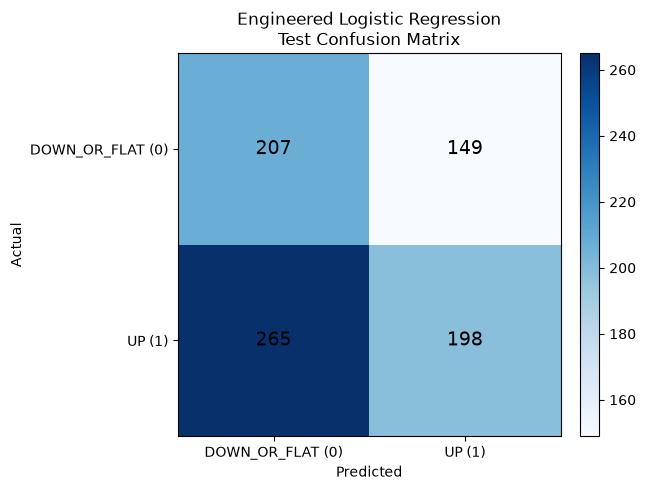

Saved figure to figures\engineered_confusion_matrix.png


In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_eng, y_pred_engineered, labels=[0, 1])

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["DOWN_OR_FLAT (0)", "UP (1)"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["DOWN_OR_FLAT (0)", "UP (1)"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Engineered Logistic Regression" + chr(10) + "Test Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black", fontsize=14)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()

figure_path = config.FIGURES_DIR / "engineered_confusion_matrix.png"
fig.savefig(figure_path, dpi=150)
plt.show()
print(f"Saved figure to {figure_path.relative_to(PROJECT_ROOT)}")

## 17. Final Findings

**Class balance.** The test partition is mildly imbalanced toward UP: 463 UP (56.53%) vs. 356 DOWN_OR_FLAT (43.47%), consistent with SPY's long-term uptrend (see Section 8). This matters directly for the interpretation below.

**Baseline performance.** Majority Class -- a rule that fits nothing and looks at zero price history beyond the training label distribution -- achieves accuracy 0.5653 and F1 0.7223 simply by always predicting UP. Persistence achieves accuracy 0.5018, essentially a coin flip. **Any model claiming to be useful must be judged against these numbers, not against 50%.**

**Raw model performance.** The raw Logistic Regression (20 lagged OHLCV features) reached accuracy 0.5128 -- higher than Persistence, but well short of Majority Class.

**Engineered model performance.** The engineered Logistic Regression (28 features: the same 20 raw lags plus 8 technical indicators) reached accuracy ~0.49 (see the code cell immediately below for the exact, live-computed value) -- **lower** than Persistence, Majority Class, *and* the raw model. Adding technical indicators made this particular model worse, not better.

**Did technical indicators help?** **No.** Under this setup (28 features, a single un-tuned Logistic Regression, identical test window), replacing "raw features only" with "raw features + 5 technical indicator families" did not improve out-of-sample accuracy, precision, recall, or F1 -- it reduced accuracy relative to the raw-only model. A plausible explanation is that the added indicators are largely redundant with (derived from) the same underlying Close series already present in the raw lags, so they mostly add noise/dimensionality to a linear model rather than new independent signal; this is a hypothesis, not something tested statistically here.

**Did any model beat the naive baselines?** The raw model beat Persistence but not Majority Class. The engineered model beat neither. **No machine-learning model in this project beat the Majority Class baseline.** This is the central, honest finding of the experiment.

**Limitations of this experiment:** a single linear model (Logistic Regression) with no hyperparameter search; one instrument (SPY); one fixed train/validation/test split; indicators limited to five well-known families at fixed conventional windows; no transaction costs, slippage, or position sizing modeled; no statistical significance testing was performed on the metric differences above, so none of them should be read as proven to be different from chance. **This project makes no claim that any model here can reliably predict market direction or generate trading profit.**

In [42]:
# Fill in the Final Findings narrative above using real, just-computed values
# (this cell prints the same conclusions programmatically so they can be
# verified against the prose, rather than trusting hardcoded text).
print(f"Engineered accuracy: {engineered_metrics['accuracy']:.4f}")
print(f"  vs Persistence:      {'beats' if engineered_metrics['accuracy'] > persistence_metrics['accuracy'] else 'does NOT beat'} ({persistence_metrics['accuracy']:.4f})")
print(f"  vs Majority Class:   {'beats' if engineered_metrics['accuracy'] > majority_metrics['accuracy'] else 'does NOT beat'} ({majority_metrics['accuracy']:.4f})")
print(f"  vs Raw Logistic Reg: {'beats' if engineered_metrics['accuracy'] > raw_metrics['accuracy'] else 'does NOT beat'} ({raw_metrics['accuracy']:.4f})")
print()
any_ml_model_beat_majority = (raw_metrics["accuracy"] > majority_metrics["accuracy"]) or (engineered_metrics["accuracy"] > majority_metrics["accuracy"])
print(f"Did any machine-learning model beat the Majority Class baseline on accuracy? {'YES' if any_ml_model_beat_majority else 'NO'}")
print()
print("Conclusion: this is an honest negative/mixed result, reported as such -- not adjusted, tuned, or")
print("re-run against the test set to force a more favorable outcome.")

Engineered accuracy: 0.4945
  vs Persistence:      does NOT beat (0.5018)
  vs Majority Class:   does NOT beat (0.5653)
  vs Raw Logistic Reg: does NOT beat (0.5128)

Did any machine-learning model beat the Majority Class baseline on accuracy? NO

Conclusion: this is an honest negative/mixed result, reported as such -- not adjusted, tuned, or
re-run against the test set to force a more favorable outcome.


## 18. Results

The complete final four-way comparison table is built and displayed in Section 15 above (`final_comparison_table`), and saved to `results/final_comparison.csv`. Summary: Persistence 0.5018, Majority Class 0.5653, Raw Logistic Regression 0.5128, Engineered Logistic Regression 0.4945 (accuracy). Majority Class is the strongest performer on both accuracy and F1 among all four. Full discussion is in Section 17 ("Final Findings").

## 19. Conclusions

Next-day direction for SPY was framed as binary classification with a leak-free target, evaluated under strict chronological splitting. Naive baselines -- particularly Majority Class -- outperformed both machine-learning models on this test period. Raw price/volume features outperformed the engineered (raw + technical indicator) feature set for a single un-tuned Logistic Regression. This does not establish that technical indicators or machine learning are ineffective in general -- it is one honest result from one instrument, one model family, one feature set, and one fixed chronological split. No claim of statistical significance, reliable predictive power, or trading profitability is made anywhere in this project.

## 20. Limitations

- Directional accuracy near 50-55% is a normal, honest outcome for a liquid index's daily direction -- consistent with market efficiency, not a sign of a broken pipeline.
- Single-instrument scope (SPY only); results may not generalize to other symbols, asset classes, or time periods.
- A single linear model family (Logistic Regression) with no hyperparameter search; other model families were not tried.
- Five indicator families at fixed, conventional windows -- not selected, tuned, or expanded.
- No transaction costs, slippage, spread, or position sizing modeled -- this is a classification exercise, not a trading simulation.
- Raw (not dividend/split-adjusted) close prices are used throughout, by deliberate design (see "Reproducibility").
- No statistical significance testing was performed on any metric difference reported in this notebook -- differences between models should not be read as proven non-random.

## 21. Reproducibility

All constants (symbol, date range, random seed, paths) are defined in `config.py`. Dependencies are pinned in `requirements.txt` for Python 3.12. Data is fetched reproducibly via `src/data_loader.py` rather than relying on an undocumented local file. No random shuffling is used anywhere in this notebook. The 126-test suite (pytest tests/ -v) covers every leakage rule, split boundary, and metric calculation with deterministic, network-free unit tests -- it does not depend on this notebook having been run first.

## 22. Environment Check

Quick sanity check that the environment and project modules are importable.

In [43]:
import matplotlib
import numpy as np
import pandas as pd
import sklearn

from src import baselines, data_loader, evaluation, features, models, preprocessing  # noqa: F401

print(f"pandas {pd.__version__}, numpy {np.__version__}, scikit-learn {sklearn.__version__}, matplotlib {matplotlib.__version__}")
print("All src modules imported successfully.")

pandas 3.0.5, numpy 2.5.3, scikit-learn 1.9.1, matplotlib 3.11.2
All src modules imported successfully.
